In [1]:
import pandas as pd
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [2]:
# Function to parse NGINX log
def parse_nginx_log(log_line):  
    pattern = (
        r'(?P<ip>\S+) \S+ \S+ \[(?P<datetime>[^\]]+)\] '
        r'"(?P<request>[^"]*)" (?P<status>\d+) (?P<size>\d+) '
        r'"(?P<referrer>[^"]*)" "(?P<user_agent>[^"]*)"'
    )
    match = re.match(pattern, log_line)
    if match:
        return match.groupdict()
    return None

# # Read and parse log file
# with open('data/old.log') as file:
#     logs = [parse_nginx_log(line) for line in file if parse_nginx_log(line) is not None]

# df = pd.DataFrame(logs)


In [3]:
# Preprocess log data
def preprocess_log(file_path):
    with open(file_path) as file:
        logs = [parse_nginx_log(line) for line in file if parse_nginx_log(line) is not None]
    df = pd.DataFrame(logs)
    
    # Extracting features
    df['method'] = df['request'].str.split().str[0]
    df['url'] = df['request'].str.split().str[1]
    df['datetime'] = pd.to_datetime(df['datetime'], format='%d/%b/%Y:%H:%M:%S %z')
    df['request_count'] = df.groupby('ip')['ip'].transform('count')
    df['time_diff'] = df.groupby('ip')['datetime'].transform(lambda x: (x.max() - x.min()).seconds)
    df['status'] = df['status'].astype(int)
    
    return df

In [4]:
# Load and preprocess the training data
df_train = preprocess_log('data/old.log')

In [5]:
# Labeling synthetic (for illustration)
df_train['label'] = 0  # 0 for normal
df_train.loc[df_train['url'].str.contains(r'UNION|SELECT|INSERT|DELETE|UPDATE', case=False, na=False), 'label'] = 1  # SQL Injection
# Brute Force Detection (assuming status 401 indicates a failed login attempt)
df_train.loc[(df_train['status'] == 401) & (df_train['request_count'] > 5), 'label'] = 2  # 2 for Brute Force
# DoS Detection (assuming high request rate in short time)
df_train.loc[(df_train['request_count'] > 100) & (df_train['time_diff'] <= 60), 'label'] = 3  # 3 for DoS


In [6]:
# Select features and train the model
features = ['request_count', 'time_diff']
X_train = df_train[features]
y_train = df_train['label'].astype(int)

In [7]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
# Load and preprocess the testing data
df_test = preprocess_log('data/new.log')

In [9]:
# Predict using the trained model
df_test['predicted_label'] = clf.predict(df_test[features])

In [10]:
# Generate classification report
y_test = df_test['predicted_label'].astype(int)
print(classification_report(y_train, clf.predict(X_train)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00  11310427
           1       0.94      0.01      0.01     32038
           2       0.89      0.01      0.01     12021
           3       1.00      1.00      1.00     11006

    accuracy                           1.00  11365492
   macro avg       0.96      0.50      0.51  11365492
weighted avg       1.00      1.00      0.99  11365492



In [11]:
# Count the number of attacks detected for each type
sql_injection_count = df_test[df_test['predicted_label'] == 1].shape[0]
brute_force_count = df_test[df_test['predicted_label'] == 2].shape[0]
dos_count = df_test[df_test['predicted_label'] == 3].shape[0]
# Add similar lines for Brute Force and DoS detection counts once labeled properly

In [12]:
print(f"Number of SQL Injection attacks detected: {sql_injection_count}")
print(f"Number of Brute Force attacks detected: {brute_force_count}")
print(f"Number of DoS attacks detected: {dos_count}")
# Print counts for other attack types similarly

Number of SQL Injection attacks detected: 239
Number of Brute Force attacks detected: 30
Number of DoS attacks detected: 2972


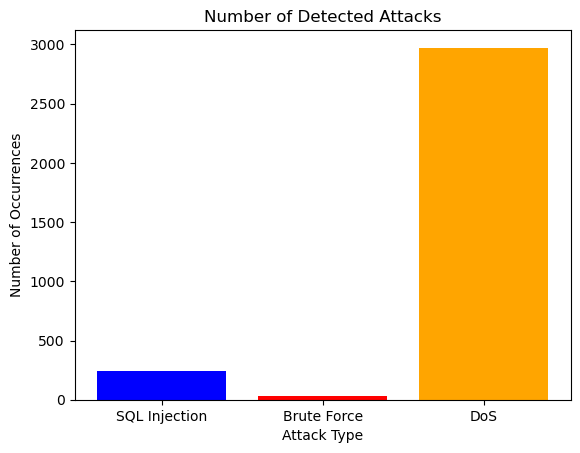

In [13]:
# Data for the plot
attack_types = ['SQL Injection', 'Brute Force', 'DoS']
attack_counts = [sql_injection_count, brute_force_count, dos_count]

# Create a bar chart
plt.bar(attack_types, attack_counts, color=['blue', 'red', 'orange'])
plt.title('Number of Detected Attacks')
plt.xlabel('Attack Type')
plt.ylabel('Number of Occurrences')
plt.show()

In [14]:
# Filter out normal logs
detected_attacks = df_test[df_test['predicted_label'] != 0]

In [15]:
# Save only detected attacks to a CSV file
detected_attacks.to_csv('detected_attacks.csv', index=False)